## Objective Fucntion

In [98]:
# To be adjusted
def calculate_suitability(row, w0=0.8, w1=0.3, w2=-0.2, w3=-0.2):
    return w0 * row['ALLSKY_SFC_SW_DWN'] + w1 * row['ALLSKY_KT'] + w2 * row['CLOUD_AMT'] + w3 * row['PRECTOTCORR']


## Genetic Algo

In [ ]:
import pandas as pd
import numpy as np
import random

def genetic_algorithm(df, population_size, generations, mutation_rate, num_points=20, verbose=False):
    df = df.copy()

    def fitness_function(point_indices):
        points = df.loc[point_indices]
        suitability_score = points['avg_score'].sum()

        # --- Grid proximity penalty ---
        penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)

                if distance_km < 100:
                    penalty += 1 / (distance_km + 1e-6)

        lambda_penalty = 10
        return suitability_score - lambda_penalty * penalty

    def create_initial_population():
        return [np.random.choice(df.index, num_points, replace=False) for _ in range(population_size)]

    def selection(population, fitnesses):
        indices = np.argsort(fitnesses)
        return [population[i] for i in indices[-(population_size // 2):]]

    def crossover(parent1, parent2):
        point = random.randint(1, len(parent1) - 1)
        child1 = np.concatenate((parent1[:point], parent2[point:]))
        child2 = np.concatenate((parent2[:point], parent1[point:]))
        return child1, child2

    def mutate(individual, mutation_rate):
        if random.random() < mutation_rate:
            idx = random.randint(0, len(individual) - 1)
            new_point = random.choice([i for i in df.index if i not in individual])
            individual[idx] = new_point

    fitness_scores = []
    population = create_initial_population()
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(generations):
        fitnesses = [fitness_function(ind) for ind in population]

        if max(fitnesses) > best_fitness:
            best_fitness = max(fitnesses)
            best_individual = population[np.argmax(fitnesses)]

        selected = selection(population, fitnesses)
        next_generation = []

        while len(next_generation) < population_size:
            parents = random.sample(selected, 2)
            offspring1, offspring2 = crossover(parents[0], parents[1])
            mutate(offspring1, mutation_rate)
            mutate(offspring2, mutation_rate)
            next_generation.extend([offspring1, offspring2])

        population = next_generation[:population_size]

        if verbose and generation % 10 == 0:
            print(f"Generation {generation + 1}, Best Fitness: {best_fitness:.4f}")

        fitness_scores.append(best_fitness)

    best_points = df.loc[best_individual]
    best_points.to_csv('best_20_points_ga_penalty.csv', index=False)
    print("Best 20 points saved to 'best_20_points_ga_penalty.csv'")

    return best_individual, best_fitness, fitness_scores


# Run the algorithm with fixed parameters
if __name__ == "__main__":
    file_path = r"C:\Users\aya20\Desktop\6.semester\optimization\optProjCode\lat_lon_avg_score.csv"
    df_input = pd.read_csv(file_path)

    
    best_assignment, best_fitness, fitness_scores = genetic_algorithm(
        df=df_input,
        population_size=50,
        generations=30,
        mutation_rate=0.25,
        num_points=20,
        verbose=True
    )


Generation 1, Best Fitness: 9.6715
Generation 11, Best Fitness: 11.7174
Generation 21, Best Fitness: 12.6589
Generation 31, Best Fitness: 12.9625
Generation 41, Best Fitness: 13.3578
Generation 51, Best Fitness: 13.4738
Generation 61, Best Fitness: 13.4771
Generation 71, Best Fitness: 13.5231
Generation 81, Best Fitness: 13.5805
Generation 91, Best Fitness: 13.6742
Generation 101, Best Fitness: 13.7677
Generation 111, Best Fitness: 13.7716
Generation 121, Best Fitness: 13.8627
Generation 131, Best Fitness: 13.8627
Generation 141, Best Fitness: 13.9569
Generation 151, Best Fitness: 13.9812
Generation 161, Best Fitness: 13.9812
Generation 171, Best Fitness: 14.0282
Generation 181, Best Fitness: 14.0282
Generation 191, Best Fitness: 14.0282
Generation 201, Best Fitness: 14.0707
Generation 211, Best Fitness: 14.0823
Generation 221, Best Fitness: 14.1287
Generation 231, Best Fitness: 14.1334
Generation 241, Best Fitness: 14.1345
Generation 251, Best Fitness: 14.1406
Generation 261, Best Fit

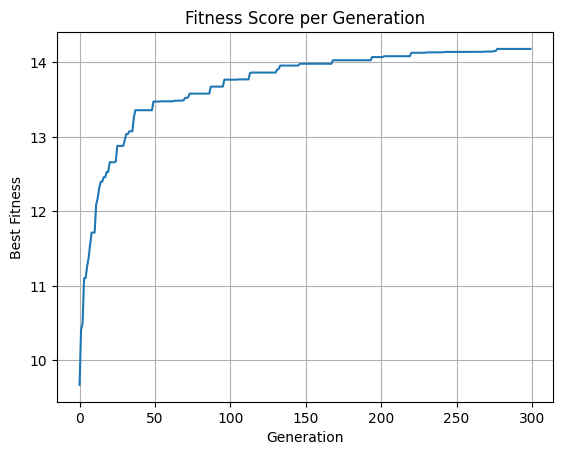

In [104]:
import matplotlib.pyplot as plt
plt.plot(fitness_scores)
plt.title("Fitness Score per Generation")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.grid()
plt.show()

In [107]:
import numpy as np
from scipy.spatial.distance import pdist

# Load both sets
ga_points = pd.read_csv("best_20_points_ga_penalty.csv")
direct_top20 = pd.read_csv("top_20_points_direct.csv")

def evaluate_point_set(df):
    coords = df[['lat', 'lon']].values
    distances = pdist(coords)  # pairwise haversine distance would be better, but Euclidean is okay for relative comparison
    mean_distance = np.mean(distances)
    mean_score = df['avg_score'].mean()
    return mean_distance, mean_score

ga_mean_distance, ga_mean_score = evaluate_point_set(ga_points)
direct_mean_distance, direct_mean_score = evaluate_point_set(direct_top20)

# Bundle results into a comparison DataFrame
comparison_df = pd.DataFrame({
    'Method': ['Genetic Algorithm', 'Top-20 Direct'],
    'Mean Distance Between Points': [ga_mean_distance, direct_mean_distance],
    'Mean Suitability Score': [ga_mean_score, direct_mean_score]
})

comparison_df


,Method,Mean Distance Between Points,Mean Suitability Score
0,Genetic Algorithm,5.655944,0.717791
1,Top-20 Direct,4.308333,0.785067


C:\Users\aya20\AppData\Local\Temp\ipykernel_10972\2540175042.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


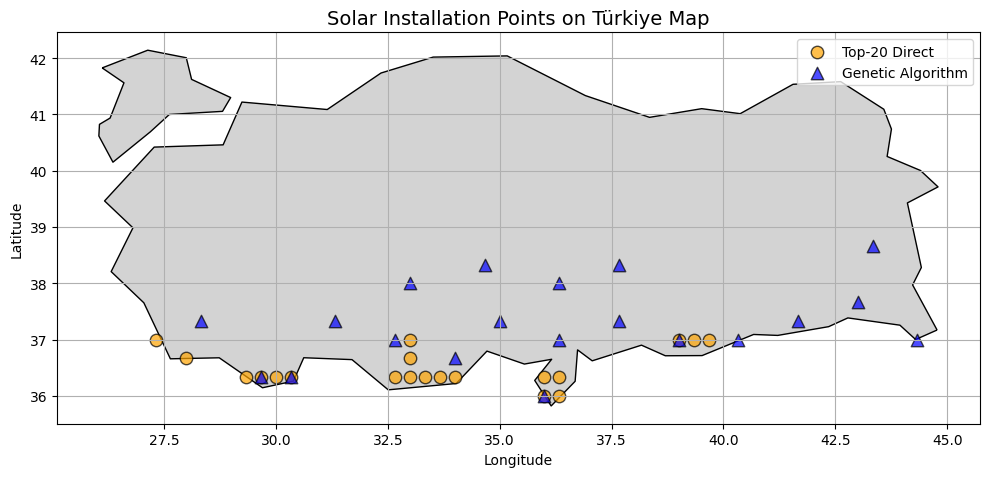

In [113]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load Turkey map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
turkey = world[world.name == "Turkey"]

# Load both datasets
ga_points = pd.read_csv('best_20_points_ga_penalty.csv')
direct_points = pd.read_csv('top_20_points_direct.csv')

# Convert to GeoDataFrames
gdf_ga = gpd.GeoDataFrame(
    ga_points,
    geometry=gpd.points_from_xy(ga_points.lon, ga_points.lat),
    crs="EPSG:4326"
)

gdf_direct = gpd.GeoDataFrame(
    direct_points,
    geometry=gpd.points_from_xy(direct_points.lon, direct_points.lat),
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
turkey.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot both sets with transparency and borders
gdf_direct.plot(ax=ax, color='orange', marker='o', markersize=80, label='Top-20 Direct', edgecolor='black', alpha=0.7)
gdf_ga.plot(ax=ax, color='blue', marker='^', markersize=80, label='Genetic Algorithm', edgecolor='black', alpha=0.7)

# Aesthetics
plt.title("Solar Installation Points on Türkiye Map", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\aya20\AppData\Local\Temp\ipykernel_10972\543603950.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


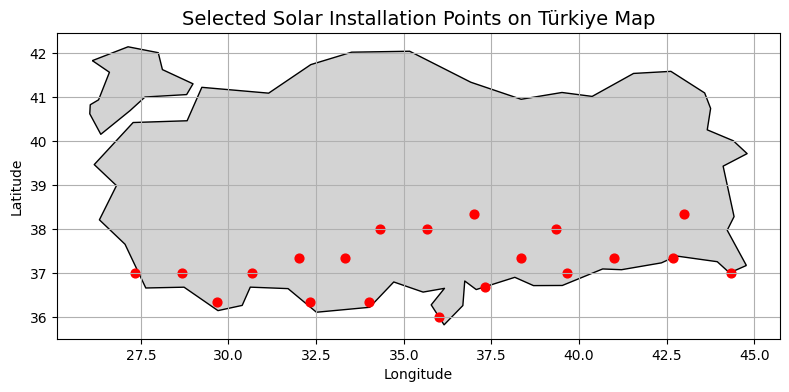

In [97]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
turkey = world[world.name == "Turkey"]

# Load the selected points
selected_points = pd.read_csv('best_20_points_ga_penalty.csv')

# Convert points to GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    selected_points,
    geometry=gpd.points_from_xy(selected_points.lon, selected_points.lat),
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(8, 10))
turkey.plot(ax=ax, color='lightgray', edgecolor='black')
gdf_points.plot(ax=ax, color='red', markersize=40)

plt.title("Selected Solar Installation Points on Türkiye Map", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\aya20\AppData\Local\Temp\ipykernel_10972\2540175042.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


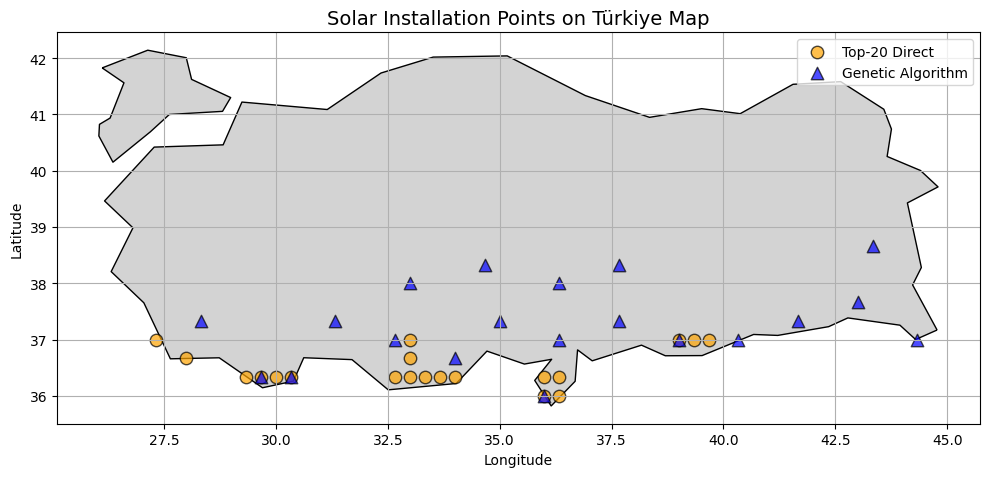

In [112]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load Turkey map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
turkey = world[world.name == "Turkey"]

# Load both datasets
ga_points = pd.read_csv('best_20_points_ga_penalty.csv')
direct_points = pd.read_csv('top_20_points_direct.csv')

# Convert to GeoDataFrames
gdf_ga = gpd.GeoDataFrame(
    ga_points,
    geometry=gpd.points_from_xy(ga_points.lon, ga_points.lat),
    crs="EPSG:4326"
)

gdf_direct = gpd.GeoDataFrame(
    direct_points,
    geometry=gpd.points_from_xy(direct_points.lon, direct_points.lat),
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
turkey.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot both sets with transparency and borders
gdf_direct.plot(ax=ax, color='orange', marker='o', markersize=80, label='Top-20 Direct', edgecolor='black', alpha=0.7)
gdf_ga.plot(ax=ax, color='blue', marker='^', markersize=80, label='Genetic Algorithm', edgecolor='black', alpha=0.7)

# Aesthetics
plt.title("Solar Installation Points on Türkiye Map", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [95]:
# Load the dataset with lat, lon, and avg_score
df = pd.read_csv("lat_lon_avg_score.csv")

# Select the top 20 points with the highest avg_score
top_20_points = df.nlargest(20, 'avg_score')

# Save to CSV
output_path_top20 = "top_20_points_direct.csv"
top_20_points.to_csv(output_path_top20, index=False)

output_path_top20


'top_20_points_direct.csv'

### Experiments with GA


In [87]:

# initializing the experiment variables
pop_size = [25,50,75,100]
mut_rate = [0.05,0.1,0.2,0.3]
gens = [100,500,1000,2000]

In [88]:
pop_results = []

for pop in pop_size:
    best_assignment, best_fitness, fitness_scores = genetic_algorithm(
        df=df_input.copy(),       # ensure original data is preserved
        population_size=pop,
        generations=100,
        mutation_rate=0.2,
        num_points=20,
        verbose=True
    )
    print(f"Population Size: {pop}, Best Fitness: {best_fitness}")
    pop_results.append([best_assignment, best_fitness, fitness_scores])


Generation 1, Best Fitness: 9.9370
Generation 11, Best Fitness: 12.2450
Generation 21, Best Fitness: 13.0791
Generation 31, Best Fitness: 13.3344
Generation 41, Best Fitness: 13.5892
Generation 51, Best Fitness: 13.6217
Generation 61, Best Fitness: 13.7126
Generation 71, Best Fitness: 13.7126
Generation 81, Best Fitness: 13.7704
Generation 91, Best Fitness: 13.8649
Best 20 points saved to 'best_20_points_ga_penalty.csv'
Population Size: 25, Best Fitness: 13.86488327890778
Generation 1, Best Fitness: 10.5472
Generation 11, Best Fitness: 12.4031
Generation 21, Best Fitness: 13.0718
Generation 31, Best Fitness: 13.5833
Generation 41, Best Fitness: 13.6084
Generation 51, Best Fitness: 13.7914
Generation 61, Best Fitness: 13.8823
Generation 71, Best Fitness: 13.8823
Generation 81, Best Fitness: 13.8823
Generation 91, Best Fitness: 13.9916
Best 20 points saved to 'best_20_points_ga_penalty.csv'
Population Size: 50, Best Fitness: 13.991602856875271
Generation 1, Best Fitness: 10.2284
Generati

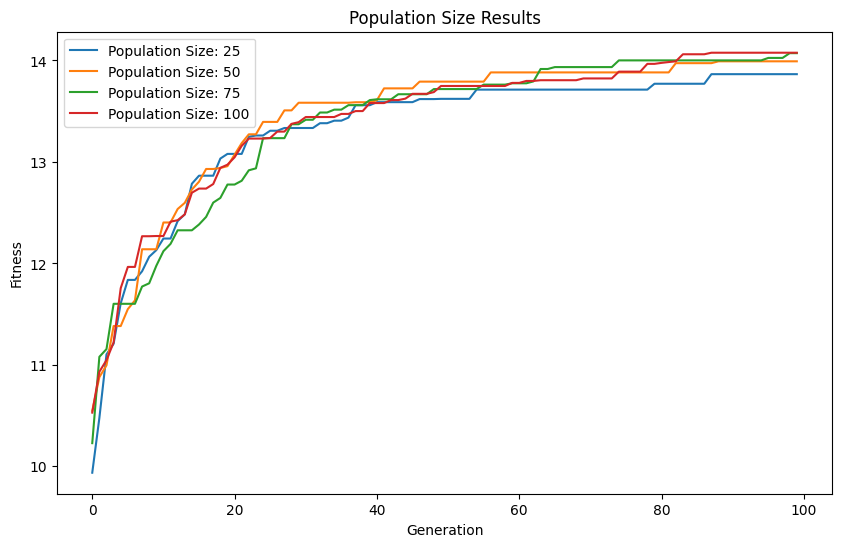

In [89]:

plt.figure(figsize=(10, 6))
for i, result in enumerate(pop_results):
    plt.plot(result[2], label=f"Population Size: {pop_size[i]}")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.title("Population Size Results")
plt.show()

In [90]:
mut_results = []
for mut in mut_rate:
    best_assignment, best_fitness, fitness_scores = best_assignment, best_fitness, fitness_scores = genetic_algorithm(
        df=df_input.copy(),       # ensure original data is preserved
        population_size=50,
        generations=100,
        mutation_rate=mut,
        num_points=20,
        verbose=True
    )
    print(f"Mutation Rate: {mut}, Best Fitness: {best_fitness}")
    mut_results.append([best_assignment, best_fitness, fitness_scores])

Generation 1, Best Fitness: 10.4903
Generation 11, Best Fitness: 12.1835
Generation 21, Best Fitness: 13.0898
Generation 31, Best Fitness: 13.2392
Generation 41, Best Fitness: 13.2392
Generation 51, Best Fitness: 13.2577
Generation 61, Best Fitness: 13.2577
Generation 71, Best Fitness: 13.4403
Generation 81, Best Fitness: 13.4403
Generation 91, Best Fitness: 13.4542
Best 20 points saved to 'best_20_points_ga_penalty.csv'
Mutation Rate: 0.05, Best Fitness: 13.454198234557602
Generation 1, Best Fitness: 9.7446
Generation 11, Best Fitness: 12.0533
Generation 21, Best Fitness: 12.7022
Generation 31, Best Fitness: 13.0713
Generation 41, Best Fitness: 13.3208
Generation 51, Best Fitness: 13.4038
Generation 61, Best Fitness: 13.5153
Generation 71, Best Fitness: 13.5153
Generation 81, Best Fitness: 13.5153
Generation 91, Best Fitness: 13.5405
Best 20 points saved to 'best_20_points_ga_penalty.csv'
Mutation Rate: 0.1, Best Fitness: 13.540492915072676
Generation 1, Best Fitness: 10.4093
Generati

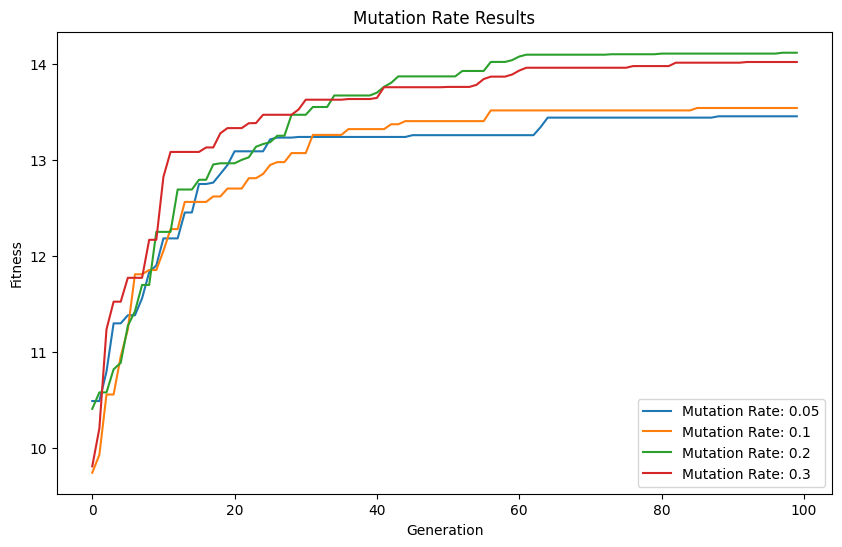

In [91]:

plt.figure(figsize=(10, 6))
for mut, result in zip(mut_rate, mut_results):
    plt.plot(result[2], label=f"Mutation Rate: {mut}")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Mutation Rate Results")
plt.legend()
plt.show()

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
file_path = r"C:\Users\aya20\Desktop\6.semester\optimization\optProjCode\lat_lon_avg_score.csv"
df_input = pd.read_csv(file_path)

# Run the genetic algorithm
best_assignment, best_fitness, fitness_scores = genetic_algorithm(
    df=df_input.copy(),
    population_size=50,
    generations=2000,
    mutation_rate=0.2,
    num_points=20,
    verbose=True
)

Generation 1, Best Fitness: 10.0839
Generation 11, Best Fitness: 12.2897
Generation 21, Best Fitness: 12.9466
Generation 31, Best Fitness: 13.2572
Generation 41, Best Fitness: 13.3288
Generation 51, Best Fitness: 13.3288
Generation 61, Best Fitness: 13.5001
Generation 71, Best Fitness: 13.7233
Generation 81, Best Fitness: 13.8385
Generation 91, Best Fitness: 14.0644
Generation 101, Best Fitness: 14.1156
Generation 111, Best Fitness: 14.1497
Generation 121, Best Fitness: 14.1672
Generation 131, Best Fitness: 14.1915
Generation 141, Best Fitness: 14.1915
Generation 151, Best Fitness: 14.1917
Generation 161, Best Fitness: 14.1952
Generation 171, Best Fitness: 14.1952
Generation 181, Best Fitness: 14.2909
Generation 191, Best Fitness: 14.2909
Generation 201, Best Fitness: 14.3115
Generation 211, Best Fitness: 14.3115
Generation 221, Best Fitness: 14.3399
Generation 231, Best Fitness: 14.3399
Generation 241, Best Fitness: 14.3687
Generation 251, Best Fitness: 14.3687
Generation 261, Best Fi

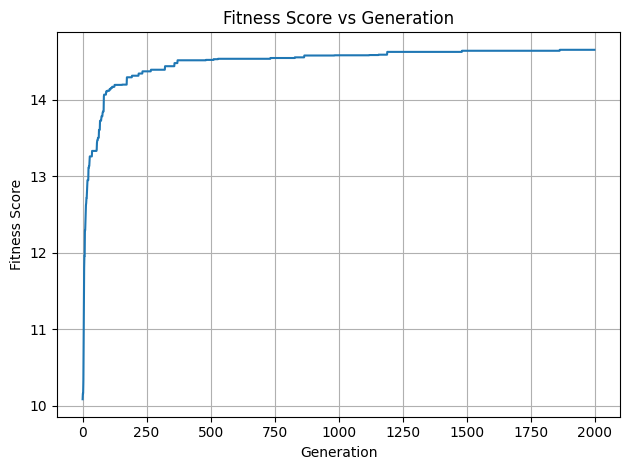

In [94]:
# Plot the fitness scores
plt.plot(fitness_scores)
plt.xlabel("Generation")
plt.ylabel("Fitness Score")
plt.title("Fitness Score vs Generation")
plt.grid(True)
plt.tight_layout()
plt.show()

## Simulated Annealing

## Particle Swarm

## Comparison